<a href="https://colab.research.google.com/github/bmxjuane/Juan-Emilio-Persichini-Data-Science-2/blob/main/Data_Science_2_(entrega_final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Disease Risk from Daily Habits**

Este dataset contiene informacion detallada acerca de habitos, metricas de salud, estilo de vida y datos biometricos de 5.000 individuos (el dataset original era demasiado extenso) con 23 variables y un objetivo, predecir si la persona tiene mas chances de tener una enfermedad de acuerdo a ciertas variables. El conjunto de datos incluye variables numéricas como edad, altura, peso, presión arterial, colesterol, glucosa, entre otras; y variables categóricas como género, tipo de dieta, nivel de ejercicio, historial familiar, etc.
Este análisis exploratorio busca identificar patrones, correlaciones y posibles factores de riesgo que puedan influir en el desarrollo de enfermedades.



# **Descripcion de las variables**

 **Datos personales y demográficos**

- survey_code: Identificador único de cada encuesta.
- age: Edad del encuestado.
- gender: Género (por ejemplo, masculino, femenino, otro).
- pet_owner: Si la persona tiene mascotas.
- family_history: Antecedentes familiares de enfermedades.

 **Medidas físicas y biométricas**

- height: Altura en metros o centímetros.
- weight: Peso en kilogramos.
- blood_pressure: Presión arterial.
- heart_rate: Frecuencia cardíaca.
- cholesterol: Nivel de colesterol.
- glucose: Nivel de glucosa.
- insulin: Nivel de insulina.

 **Hábitos diarios**

- sleep_hours: Horas de sueño por día.
- physical_activity: Nivel de actividad física (minutos o escala).
- daily_steps: Cantidad de pasos diarios.
- screen_time: Tiempo frente a pantallas.
- water_intake: Consumo de agua diario.
- caffeine_intake: Consumo de cafeína (ej. bajo, medio, alto).
- calorie_intake: Ingesta calórica diaria.
- sugar_intake: Consumo de azúcar diario.
- alcohol_consumption: Consumo de alcohol (ej. nunca, ocasional, frecuente).
- smoking_level: Nivel de tabaquismo.
- diet_type: Tipo de dieta (ej. vegetariana, balanceada, alta en grasas).
- exercise_type: Tipo de ejercicio realizado.



- target: Variable objetivo (probablemente indica si la persona tiene riesgo de enfermedad o no).

Como primera medida vamos a importar las librerias que vamos a utilizar

In [442]:
import numpy as np
import pandas as pd
import os
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [443]:
df = pd.read_csv('/content/health_lifestyle.csv')

In [444]:
df.head(5)

,survey_code,age,gender,height,weight,blood_pressure,heart_rate,cholesterol,glucose,insulin,...,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,diet_type,exercise_type,family_history,pet_owner,target
0,1,56,Male,173.416872,56.886640,118.264254,60.749825,214.580523,103.008176,NaN,...,44.476887,NaN,Non-smoker,1.694262,5.003963,Vegan,Strength,No,Yes,healthy
1,2,69,Female,163.207380,97.799859,117.917986,66.463696,115.794002,116.905134,10.131597,...,74.663405,Regularly,Light,0.716409,5.925455,Vegan,Cardio,Yes,No,healthy
2,3,46,Male,177.281966,80.687562,123.073698,76.043212,138.134787,89.180302,NaN,...,19.702382,Regularly,Heavy,2.487900,4.371250,Vegan,Cardio,No,No,healthy
3,4,32,Female,172.101255,63.142868,148.173453,68.781981,203.017447,128.375798,18.733179,...,82.580050,Occasionally,Heavy,2.643335,4.116064,Vegetarian,Mixed,No,Yes,healthy
4,5,60,Female,163.608816,40.000000,150.613180,92.335358,200.412439,94.813332,16.038701,...,45.961322,NaN,Heavy,1.968393,3.180087,Vegan,NaN,Yes,Yes,healthy


Vamos a analizar la variable "weight" y ver si tenemos outliers que puedan afectar el analisis.

In [445]:
conteo_kilos = (df['weight'] <= 42).sum()
print (conteo_kilos)

169


Tenemos 1083 casos que no superan los 42 kilos (minimo establecido lo que se entiende como un error para el objetivo de analisis que estamos haciendo ya que ese peso puede obedecer a enfermedades ya preexistentes.

Lo que vamos a hacer es reemplazar todos los casos en que el peso es menor a 42 por el peso mas repetido que es 70

In [446]:
print(df['weight'].describe())

count    5000.000000
mean       70.039525
std        14.720655
min        40.000000
25%        60.047897
50%        69.822571
75%        79.622685
max       129.240666
Name: weight, dtype: float64


In [447]:
condicion = df['weight'] < 42
df.loc[condicion, 'weight'] = 70

In [448]:
print(df['weight'].describe())

count    5000.000000
mean       71.044943
std        13.626600
min        42.038628
25%        61.591505
50%        70.000000
75%        79.622685
max       129.240666
Name: weight, dtype: float64


In [449]:
df.columns

Index(['survey_code', 'age', 'gender', 'height', 'weight', 'blood_pressure',
       'heart_rate', 'cholesterol', 'glucose', 'insulin', 'sleep_hours',
       'work_hours', 'physical_activity', 'daily_steps', 'calorie_intake',
       'sugar_intake', 'alcohol_consumption', 'smoking_level', 'water_intake',
       'screen_time', 'diet_type', 'exercise_type', 'family_history',
       'pet_owner', 'target'],
      dtype='object')

In [450]:
df.shape

(5000, 25)

In [451]:
# Resumen estadistico de las variables categoricas
df.describe(include=['object']).T

,count,unique,top,freq
gender,5000,2,Female,2526
alcohol_consumption,2848,2,Occasionally,1432
smoking_level,5000,3,Heavy,1685
diet_type,5000,4,Vegan,1307
exercise_type,3691,3,Mixed,1235
family_history,5000,2,No,2510
pet_owner,5000,2,No,2535
target,5000,2,healthy,3499


In [452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   survey_code          5000 non-null   int64  
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   object 
 3   height               5000 non-null   float64
 4   weight               5000 non-null   float64
 5   blood_pressure       4609 non-null   float64
 6   heart_rate           4307 non-null   float64
 7   cholesterol          5000 non-null   float64
 8   glucose              5000 non-null   float64
 9   insulin              4224 non-null   float64
 10  sleep_hours          5000 non-null   float64
 11  work_hours           5000 non-null   float64
 12  physical_activity    5000 non-null   float64
 13  daily_steps          4600 non-null   float64
 14  calorie_intake       5000 non-null   float64
 15  sugar_intake         5000 non-null   f

In [453]:
# Verificamos que cantidad de valores nulos hay en cada columna (variable)
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
blood_pressure,391
heart_rate,693
cholesterol,0
glucose,0
insulin,776


La variable "alcohol_consumption" tiene aproximadamente un 40% de valores nulos, procederemos a eliminarla ya que es un porcentaje alto de valores nulos y no es una columna determinante en la busqueda de hipotesis.

Lo mismo haremos con las variables "heart_rate", "insulin", "pet_owner" y "exercise_type".

---



In [454]:
df.drop(['alcohol_consumption', 'heart_rate', 'pet_owner', 'insulin', 'exercise_type'], axis=1, inplace=True)

Ahora procedemos a realizar **analisis univariado** de algunas variables:

In [455]:
print(df['sleep_hours'].describe())

count    5000.000000
mean        6.993374
std         1.478104
min         3.000000
25%         5.999519
50%         7.016520
75%         8.011398
max        12.000000
Name: sleep_hours, dtype: float64


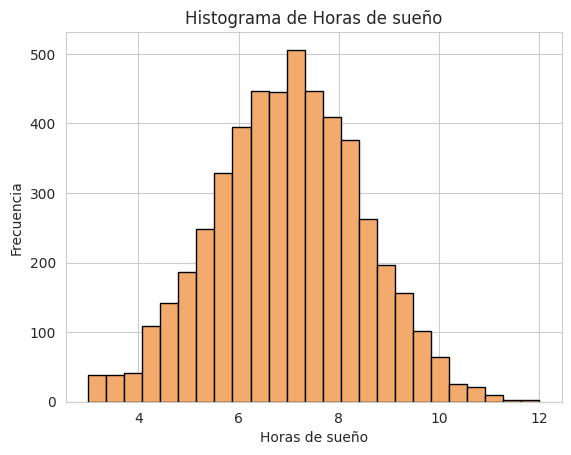

In [456]:
df['sleep_hours'].hist(bins=25, color='#F2AB6D', edgecolor='black')
plt.xlabel('Horas de sueño')
plt.ylabel('Frecuencia')
plt.title('Histograma de Horas de sueño')
plt.grid(True)
plt.show()

Con este grafico podemos afirmar que la mayoria de las personas duerme 7 horas

Ahora veremos analizaremos el tiempo que pasan las personas usando pantallas (celular, computadora, tablet, etc)

In [457]:
print(df['screen_time'].describe())

count    5000.000000
mean        6.008625
std         2.976695
min         0.000000
25%         3.926005
50%         5.923731
75%         8.077945
max        16.000000
Name: screen_time, dtype: float64


¿Cuantos casos hay en los que la persona indicó que no usa pantallas?

In [458]:
conteo_ceros = (df['screen_time'] == 0).sum()
print (conteo_ceros)

109


A continuacion veremos en un histograma, el tiempo que las personas pasan frente a una pantalla y que cantidad de horas es la mas comun.

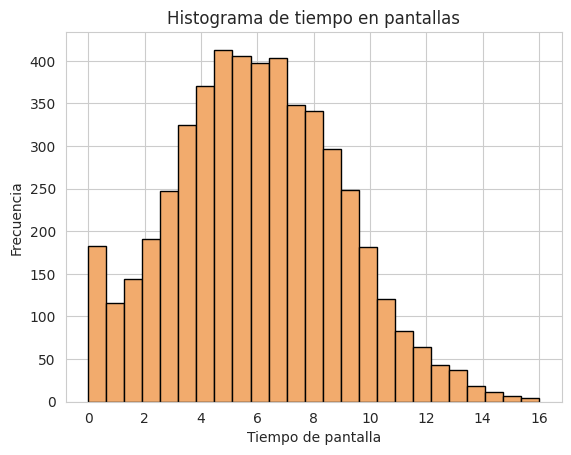

In [459]:
df['screen_time'].hist(bins=25, color='#F2AB6D', edgecolor='black')
plt.xlabel('Tiempo de pantalla')
plt.ylabel('Frecuencia')
plt.title('Histograma de tiempo en pantallas')
plt.grid(True)
plt.show()

La distribucion esta levemente sesgada a la derecha. Podemos afirmar que la mayoria de las personas pasan alrededor de 6hs frente a una pantalla.

Ahora veremos que **tipo de dieta** hacen los individuos estudiados y la cantidad que hay en cada grupo.

In [460]:
print(df['diet_type'].describe())

count      5000
unique        4
top       Vegan
freq       1307
Name: diet_type, dtype: object


Text(0.5, 1.0, 'Distribución segun tipo de dieta')

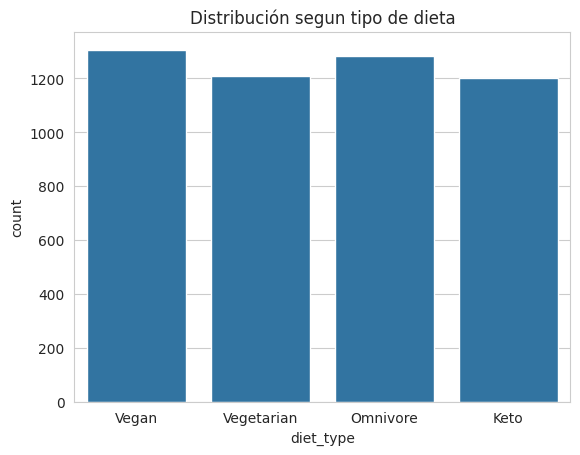

In [461]:
sns.countplot(x='diet_type', data=df)
plt.title('Distribución segun tipo de dieta')

In [462]:
conteo_grupos = df['diet_type'].value_counts()
print(conteo_grupos)

diet_type
Vegan         1307
Omnivore      1283
Vegetarian    1210
Keto          1200
Name: count, dtype: int64


Luego vamos a ver que tipo de dieta se repite mas entre hombres y mujeres

Text(0, 0.5, 'Cantidad de Personas')

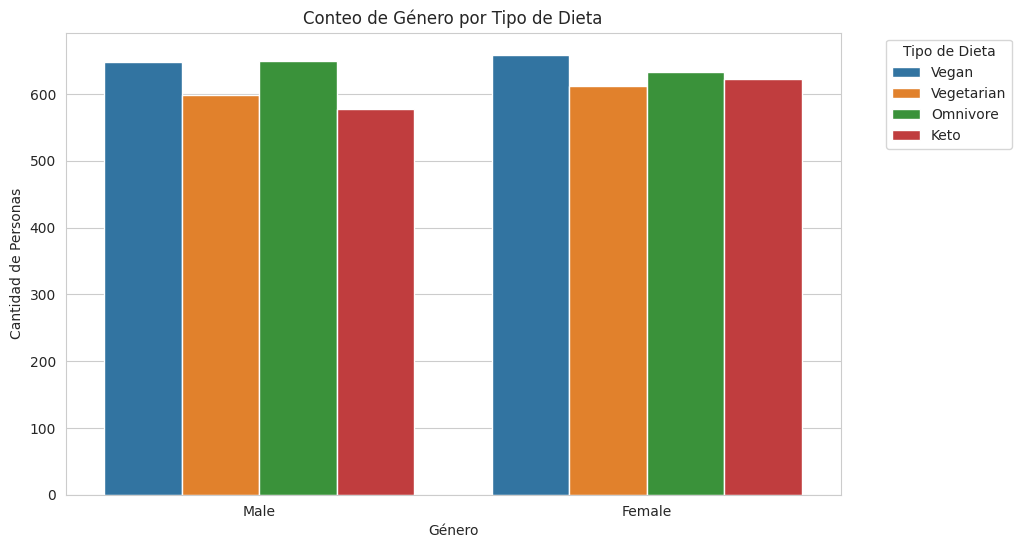

In [463]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', hue='diet_type', data=df)
plt.legend(title='Tipo de Dieta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Conteo de Género por Tipo de Dieta')
plt.xlabel('Género')
plt.ylabel('Cantidad de Personas')

Podemos determinar la dieta mas elegida por los hombres y mujeres es "Vegan"

Veremos otro grafico que detalla la cantidad exacta de individuos segun el tipo de dieta que tienen.

<Axes: xlabel='gender', ylabel='diet_type'>

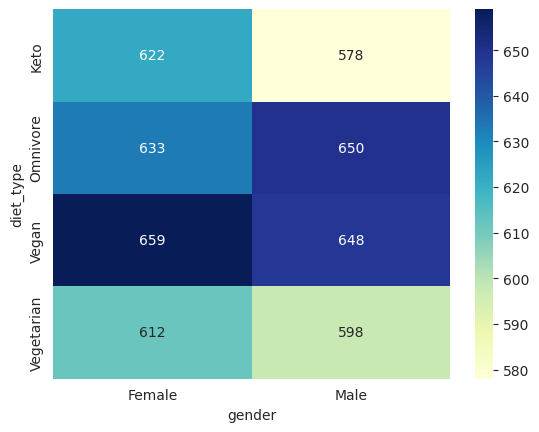

In [464]:
tabla_crosstab = pd.crosstab(df['diet_type'], df['gender']); sns.heatmap(tabla_crosstab, annot=True, fmt='d', cmap='YlGnBu')

Vamos a ver algunos aspectos de la variable "height" (Analisis univariado)

In [465]:
media_height = df['height'].mean()

In [466]:
valores_inferiores = df['height'] < media_height
conteo_inferiores = valores_inferiores.sum()

In [467]:
valores_superiores = df['height'] > media_height
conteo_superiores = valores_superiores.sum()

In [468]:
print(f"La media de 'height' es: {media_height:.2f}")
print(f"Valores inferiores a la media: {conteo_inferiores}")
print(f"Valores superiores a la media: {conteo_superiores}")

La media de 'height' es: 169.83
Valores inferiores a la media: 2477
Valores superiores a la media: 2523


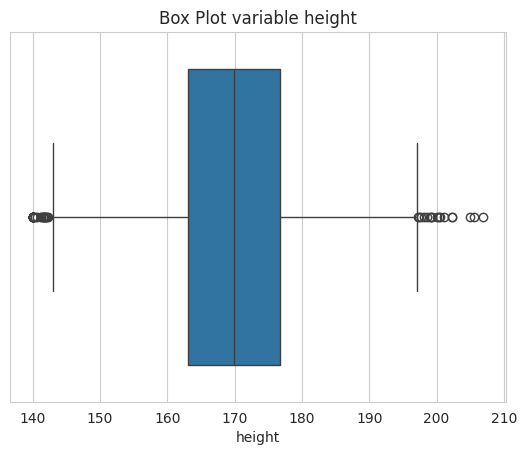

In [469]:
sns.boxplot(x=df['height'])
plt.title('Box Plot variable height')
plt.show()

No vemos una cantidad considerable de outliers en esta variable que puedan sesgar el objetivo del proyecto

Pero si vamos a clasificar las variables en categoricas o numericas para proceder con su normalizacion y codificacion

**Variables Numericas**

age: Edad.

height: Altura.

weight: Peso.

blood_pressure: Presión arterial.

cholesterol: Nivel de colesterol.

glucose: Nivel de glucosa.

sleep_hours: Horas de sueño.

physical_activity: Nivel de actividad física.

daily_steps: Pasos diarios.

screen_time: Tiempo frente a pantallas.

water_intake: Consumo de agua.

calorie_intake: Ingesta calórica.

sugar_intake: Consumo de azúcar.

**Variables categoricas**

survey_code: Identificador único.

gender: Género.

family_history: Antecedentes familiares.

caffeine_intake: Consumo de cafeína.

smoking_level: Nivel de tabaquismo.

diet_type: Tipo de dieta.

exercise_type: Tipo de ejercicio.

target: Variable objetivo (sano/no sano).

In [470]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [471]:
# Lista de columnas actuales
remaining_columns = df.columns.tolist()

# # Definimos las características basándonos en las columnas restantes, excluyendo 'target'
numeric_features = [col for col in remaining_columns if df[col].dtype in ['int64', 'float64'] and col not in ['survey_code']]
categorical_features = [col for col in remaining_columns if df[col].dtype == 'object' and col not in ['target', 'survey_code']]

In [472]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Transformar variables categoricas y numericas
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Creamos un transformador de columnas para aplicar diferentes transformaciones a diferentes columnas, excluyendo 'objetivo'
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like 'survey_code')
)

In [473]:
# Aplicamos los pasos de preprocesamiento a las variables (sin inclui a la variable 'target')
X_transformed_array = preprocessor.fit_transform(df.drop('target', axis=1))

In [474]:
# Obtenemos el nombre de las columnas creadas por OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Obtenemos nombre de las columnas que no son categoricas ni numericas, en este caso la columna indice y la variable objetivo "target"
passthrough_features = [col for col in df.columns if col not in numeric_features + categorical_features]

# Combinamos los nombres de las columnas numericas, las categoricas que fueron codificadas y la objetivo
all_feature_names = list(numeric_features) + list(ohe_feature_names) + passthrough_features

In [475]:
# Creamos un nuevo df, teniendo en cuenta los tipos de datos
df_transformed = pd.DataFrame(df_transformed_array, columns=all_feature_names)

# Convertimos las columnas a tipo de dato float64, excluyendo 'survey_code' y 'target'
for col in df_transformed.columns:
    if col not in ['survey_code', 'target']:
        df_transformed[col] = df_transformed[col].astype('float64')

In [476]:
print("Estadísticas de las variables numéricas normalizadas:")
print(df_transformed[numeric_features].describe().round(2))

Estadísticas de las variables numéricas normalizadas:
            age    height    weight  blood_pressure  cholesterol   glucose  \
count  35000.00  35000.00  35000.00        32290.00     35000.00  35000.00   
mean       0.00     -0.00     -0.00            0.00        -0.00      0.00   
std        1.00      1.00      1.00            1.00         1.00      1.00   
min       -1.70     -3.00     -2.11           -3.91        -4.08     -4.20   
25%       -0.87     -0.67     -0.71           -0.67        -0.68     -0.67   
50%       -0.03      0.01     -0.07           -0.00         0.01      0.00   
75%        0.87      0.67      0.66            0.68         0.67      0.67   
max        1.70      4.01      4.56            4.25         4.16      4.22   

       sleep_hours  work_hours  physical_activity  daily_steps  \
count     35000.00    35000.00           35000.00     32083.00   
mean         -0.00        0.00               0.00         0.00   
std           1.00        1.00               

Comprobamos que todas las variables son numericas:

In [477]:
print(df_transformed.dtypes)

age                         float64
height                      float64
weight                      float64
blood_pressure              float64
cholesterol                 float64
glucose                     float64
sleep_hours                 float64
work_hours                  float64
physical_activity           float64
daily_steps                 float64
calorie_intake              float64
sugar_intake                float64
water_intake                float64
screen_time                 float64
gender_Female               float64
gender_Male                 float64
smoking_level_Heavy         float64
smoking_level_Light         float64
smoking_level_Non-smoker    float64
diet_type_Keto              float64
diet_type_Omnivore          float64
diet_type_Vegan             float64
diet_type_Vegetarian        float64
family_history_No           float64
family_history_Yes          float64
survey_code                  object
target                       object
dtype: object


In [478]:
print(df_transformed.head())

        age    height    weight  blood_pressure  cholesterol   glucose  \
0  0.418664  0.344842 -1.026056       -0.108826     0.814932  0.154527   
1  1.144901 -0.678566  1.943261       -0.131894    -2.475032  0.852762   
2 -0.139980  0.732282  0.701319        0.211574    -1.731000 -0.540236   
3 -0.922082  0.212963 -0.572004        1.883693     0.429838  1.429091   
4  0.642121 -0.638325 -0.074341        2.046225     0.343081 -0.257212   

   sleep_hours  work_hours  physical_activity  daily_steps  ...  \
0    -0.354090   -0.161565          -1.420619     2.533054  ...   
1     0.957435    0.761875          -1.308266     1.967767  ...   
2    -0.873804   -1.083791           0.391203    -1.615915  ...   
3    -1.218959    0.749101          -1.137449    -0.674598  ...   
4     0.610904   -0.359819          -0.067562     1.117746  ...   

   smoking_level_Light  smoking_level_Non-smoker  diet_type_Keto  \
0                  0.0                       1.0             0.0   
1               

Ahora procedemos a separar las distintas features de la variable objetivo ("target)

In [479]:
# Separamos las caracteristicas (X) y la variable objetivo (y)
X = df_transformed.drop('target', axis=1)
y = df_transformed['target']

In [480]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [481]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [482]:
y_pred = model.predict(X_test)

In [483]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Exactitud (Accuracy)
# Medimos la proporcion de predicciones correctas sobre el total
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {accuracy:.4f}")

Exactitud (Accuracy): 0.7096


In [484]:
# 2. Matriz de Confusión
# Muestra el número de aciertos y errores por clase
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión:")
print(conf_matrix)



Matriz de Confusión:
[[   5 2013]
 [  20 4962]]


In [485]:
# 3. Reporte de Clasificación
# Muestra métricas detalladas por clase (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred)
print("\nReporte de Clasificación:")
print(class_report)


Reporte de Clasificación:
              precision    recall  f1-score   support

    diseased       0.20      0.00      0.00      2018
     healthy       0.71      1.00      0.83      4982

    accuracy                           0.71      7000
   macro avg       0.46      0.50      0.42      7000
weighted avg       0.56      0.71      0.59      7000



Podemos ver que el modelo esta altamente desbalanceado y sus predicciones no son buenas. Trataremos de ajustarlo para mejorar sus errores.

In [507]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [512]:
# Incluimos 'class_weight' para abordar el desbalance, lo cual es CRUCIAL.
param_grid = {
    'n_estimators': [50],
    'max_depth': [10],
    'min_samples_split': [2],
    'class_weight': [None, 'balanced']
}

In [513]:
rf = RandomForestClassifier(random_state=42)

In [514]:
grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    scoring='f1',       # Optimizar para F1-Score (mejor para desbalance)
    cv=2,
    verbose=2,
    n_jobs=-1
)

In [515]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("\n--- Reporte de Clasificación del Modelo Ajustado ---")
print(classification_report(y_test, y_pred_tuned, target_names=['diseased', 'healthy']))

Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(



--- Reporte de Clasificación del Modelo Ajustado ---
              precision    recall  f1-score   support

    diseased       0.00      0.00      0.00      2018
     healthy       0.71      1.00      0.83      4982

    accuracy                           0.71      7000
   macro avg       0.36      0.50      0.42      7000
weighted avg       0.51      0.71      0.59      7000

